In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/gpu_synapse/next_fifty/

/content/drive/MyDrive/gpu_synapse/next_fifty


In [ ]:
%cd /content/drive/MyDrive/gpu_synapse/next_fifty/

/content/drive/MyDrive/gpu_synapse/next_fifty


In [ ]:
!pip install nibabel


Loaded shapes:
Image: (512, 512, 147)
GT: (512, 512, 147)
Prediction: (512, 512, 147)


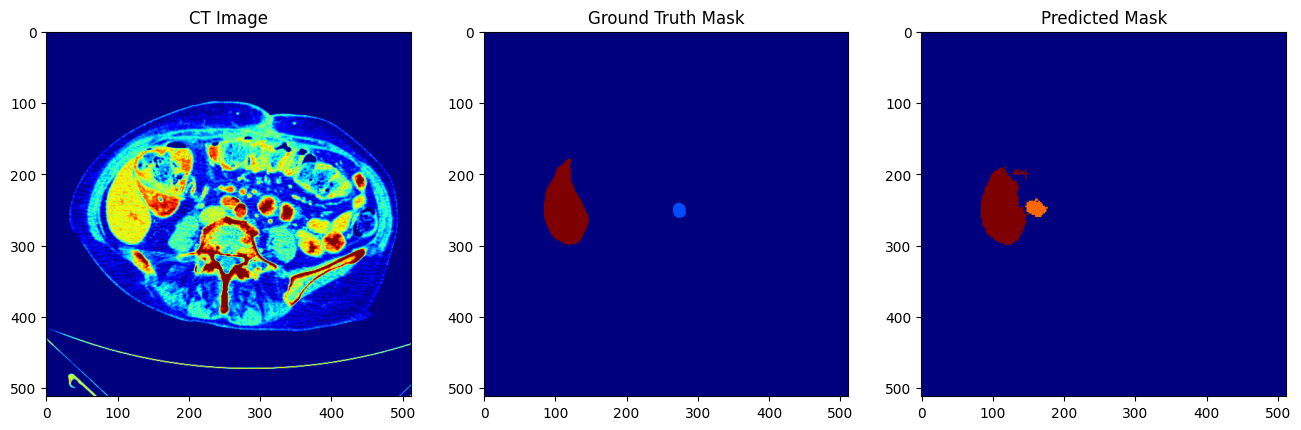

In [ ]:

# ================================
#   IMPORTS
# ================================
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ================================
#   LOAD FILES
# ================================
# Change this folder path if yours is different:
base = "/content/drive/MyDrive/gpu_synapse/next_fifty/outputs"

img_path  = f"{base}/case0001_img.nii.gz"
gt_path   = f"{base}/case0001_gt.nii.gz"
pred_path = f"{base}/case0001_pred.nii.gz"

img  = nib.load(img_path).get_fdata()
gt   = nib.load(gt_path).get_fdata()
pred = nib.load(pred_path).get_fdata()

print("Loaded shapes:")
print("Image:", img.shape)
print("GT:", gt.shape)
print("Prediction:", pred.shape)

# ================================
#   SINGLE SLICE VISUALIZATION
# ================================
slice_idx = img.shape[2] // 2  # middle slice

plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
plt.imshow(img[:,:,slice_idx], cmap='jet')
plt.title("CT Image")

plt.subplot(1,3,2)
plt.imshow(gt[:,:,slice_idx], cmap='jet')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(pred[:,:,slice_idx], cmap='jet')
plt.title("Predicted Mask")
plt.savefig("single_slice.png", dpi=300)
plt.show()

# ================================
# #   OVERLAY VISUALIZATION
# # ================================
# plt.figure(figsize=(3,3))
# plt.imshow(img[:,:,slice_idx], cmap='jet')
# plt.imshow(pred[:,:,slice_idx], cmap='jet', alpha=0.4)
# plt.title("Prediction Overlay on CT")
# plt.show()

# # ================================
# #   INTERACTIVE SCROLLING
# # ================================
# def view_slice(i):
#     plt.figure(figsize=(6,6))
#     plt.imshow(img[:,:,i], cmap='gray')
#     plt.imshow(pred[:,:,i], cmap='jet', alpha=0.4)
#     plt.title(f"Slice {i}")
#     plt.show()

# slider = widgets.IntSlider(min=0, max=img.shape[2]-1, step=1, value=slice_idx)
# widgets.interact(view_slice, i=slider)


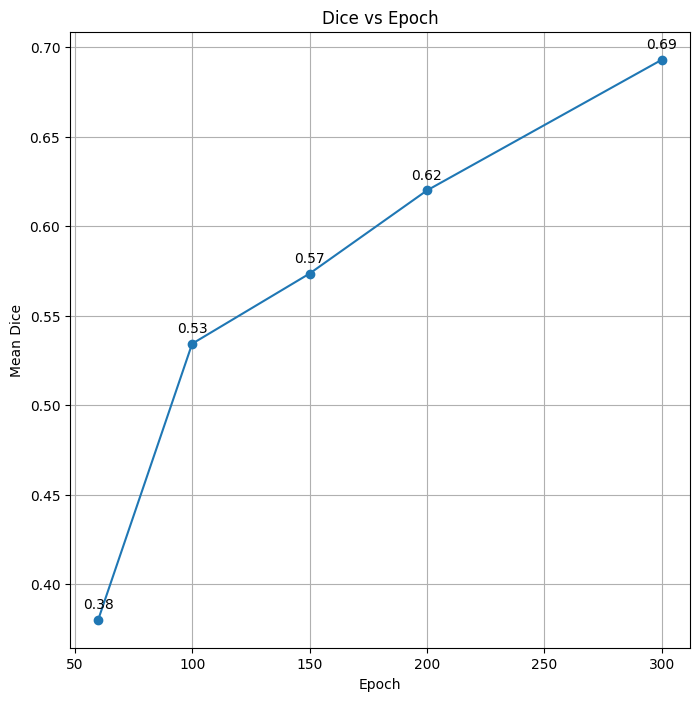

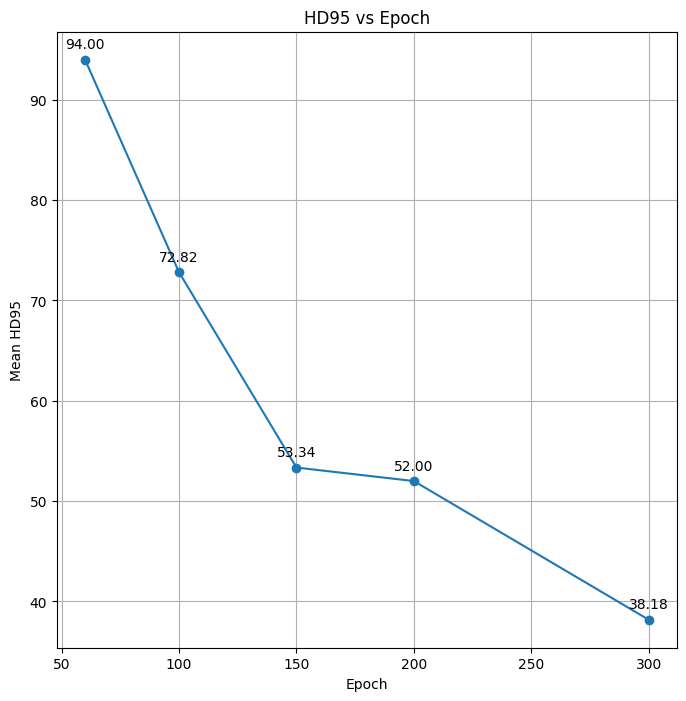

In [ ]:
import matplotlib.pyplot as plt

# Data
epochs = [60, 100, 150, 200, 300]
dice = [0.38, 0.5342939976483353, 0.5735068497089868, 0.62, 0.6930600373270095]
hd95 = [94, 72.81608204029435, 53.344665153139566, 52, 38.17725151015807]

# ---- Dice vs Epoch ----
plt.figure(figsize=(8, 8))  # enlarged figure
plt.plot(epochs, dice, marker='o')

# Annotate points (2 decimals)
for e, d in zip(epochs, dice):
    plt.annotate(f"{d:.2f}", (e, d), textcoords="offset points", xytext=(0,8), ha='center')

plt.xlabel("Epoch")
plt.ylabel("Mean Dice")
plt.title("Dice vs Epoch")
plt.grid(True)
plt.savefig("dice_vs_epoch.png", dpi=300)
plt.show()
plt.close()

# ---- HD95 vs Epoch ----
plt.figure(figsize=(8,8))  # enlarged figure
plt.plot(epochs, hd95, marker='o')

# Annotate points (2 decimals)
for e, h in zip(epochs, hd95):
    plt.annotate(f"{h:.2f}", (e, h), textcoords="offset points", xytext=(0,8), ha='center')

plt.xlabel("Epoch")
plt.ylabel("Mean HD95")
plt.title("HD95 vs Epoch")
plt.grid(True)
plt.savefig("hd95_vs_epoch.png", dpi=300)
plt.show()
plt.close()


In [ ]:
import numpy as np
import glob
from collections import Counter

label_files = glob.glob("/content/drive/MyDrive/gpu_synapse/train_npz/*.npz")

counter = Counter()

for lf in label_files:
    data = np.load(lf)
    mask = data["label"]         # 2D segmentation mask
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        counter[int(u)] += int(c)

# ---- Compute percentages ----
total_pixels = sum(counter.values())

print("Class | Pixels | Percentage")
for cls, pix in counter.items():
    percent = (pix / total_pixels) * 100
    print(f"{cls:5d} | {pix:10d} | {percent:8.3f}%")


Class | Pixels | Percentage
    0 |   55462877 |   95.735%
    1 |      85826 |    0.148%
    3 |     141878 |    0.245%
    4 |     128608 |    0.222%
    7 |     271632 |    0.469%
    5 |    1413222 |    2.439%
    2 |      27555 |    0.048%
    6 |      66737 |    0.115%
    8 |     335489 |    0.579%


In [ ]:
import numpy as np
import glob
from collections import Counter

# Load all label npz files
label_files = glob.glob("/content/drive/MyDrive/gpu_synapse/train_npz/*.npz")

counter = Counter()

# Count pixels from each file
for lf in label_files:
    data = np.load(lf)
    mask = data["label"]               # (H, W) label map
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        counter[int(u)] += int(c)

# ---- Remove background (class 0) ----
if 0 in counter:
    del counter[0]

# ---- Compute percent distribution ----
total_pixels = sum(counter.values())
percentages = {cls: (count / total_pixels) * 100 for cls, count in counter.items()}

print("Pixel Counts:", counter)
print("\nPercentage Distribution (excluding background):")
for cls, pct in percentages.items():
    print(f"Class {cls}: {pct:.2f}%")


Pixel Counts: Counter({5: 1413222, 8: 335489, 7: 271632, 3: 141878, 4: 128608, 1: 85826, 6: 66737, 2: 27555})

Percentage Distribution (excluding background):
Class 1: 3.47%
Class 3: 5.74%
Class 4: 5.20%
Class 7: 10.99%
Class 5: 57.19%
Class 2: 1.12%
Class 6: 2.70%
Class 8: 13.58%


In [ ]:
import numpy as np
import glob
from collections import Counter

# Load all label npz files
label_files = glob.glob("/content/drive/MyDrive/gpu_synapse/train_npz/*.npz")

counter = Counter()
k=0
# Count pixels from each file
for lf in label_files:
    k=k+1
    data = np.load(lf)
    mask = data["label"]               # (H, W) label map
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        counter[int(u)] += int(c)

# ---- Remove background (class 0) ----
if 0 in counter:
    del counter[0]

# ---- Compute percent distribution ----
total_pixels = sum(counter.values())
percentages = {cls: (count / total_pixels) * 100 for cls, count in counter.items()}
print(k)
print("Pixel Counts:", counter)
print("\nPercentage Distribution (excluding background):")
for cls, pct in percentages.items():
    print(f"Class {cls}: {pct:.2f}%")


221
Pixel Counts: Counter({5: 1413222, 8: 335489, 7: 271632, 3: 141878, 4: 128608, 1: 85826, 6: 66737, 2: 27555})

Percentage Distribution (excluding background):
Class 1: 3.47%
Class 3: 5.74%
Class 4: 5.20%
Class 7: 10.99%
Class 5: 57.19%
Class 2: 1.12%
Class 6: 2.70%
Class 8: 13.58%


In [ ]:
import numpy as np
import glob
from collections import Counter

# Load all label npz files
label_files = glob.glob("/content/drive/MyDrive/project_TransUNet/data/Synapse/train_npz/*.npz")

counter = Counter()
k=0
# Count pixels from each file
for lf in label_files:
    k=k+1
    data = np.load(lf)
    mask = data["label"]               # (H, W) label map
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        counter[int(u)] += int(c)

# ---- Remove background (class 0) ----
if 0 in counter:
    del counter[0]

# ---- Compute percent distribution ----
total_pixels = sum(counter.values())
percentages = {cls: (count / total_pixels) * 100 for cls, count in counter.items()}
print(k)
print("Pixel Counts:", counter)
print("\nPercentage Distribution (excluding background):")
for cls, pct in percentages.items():
    print(f"Class {cls}: {pct:.2f}%")


2211
Pixel Counts: Counter({5: 14192919, 8: 3474831, 7: 3119429, 3: 1344662, 4: 1333973, 1: 922056, 6: 651861, 2: 245028})

Percentage Distribution (excluding background):
Class 3: 5.32%
Class 4: 5.28%
Class 1: 3.65%
Class 7: 12.34%
Class 6: 2.58%
Class 5: 56.13%
Class 8: 13.74%
Class 2: 0.97%


In [ ]:
%cd /content/drive/MyDrive/gpu_synapse/next_fifty
!ls

/content/drive/MyDrive/gpu_synapse/next_fifty
checkpoints  dice_vs_epoch.png	hd95_vs_epoch.png  log	outputs


In [ ]:
%pwd

'/content/drive/.shortcut-targets-by-id/1FTGWdCLE0XRLzqrkRt55D9GnFIALowrJ/synapse_features'

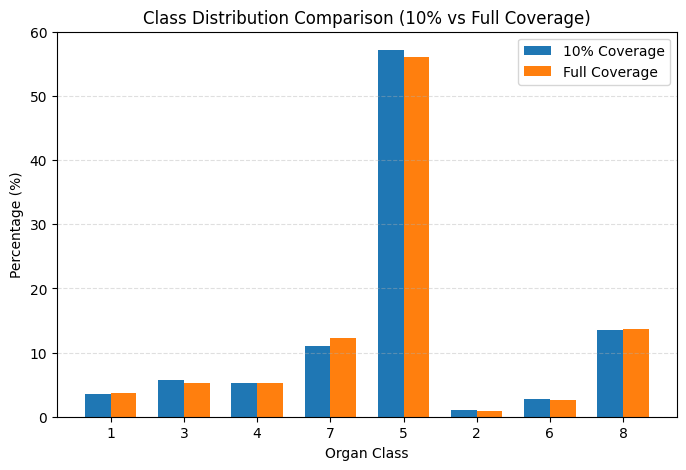

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- YOUR DATA ----------
classes = [1,3,4,7,5,2,6,8]

percent_10 = [3.47, 5.74, 5.20, 10.99, 57.19, 1.12, 2.70, 13.58]
percent_full = [3.65, 5.32, 5.28, 12.34, 56.13, 0.97, 2.58, 13.74]

# ---------- VISUALISATION ----------
x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, percent_10, width, label='10% Coverage')
plt.bar(x + width/2, percent_full, width, label='Full Coverage')

plt.xlabel("Organ Class")
plt.ylabel("Percentage (%)")
plt.title("Class Distribution Comparison (10% vs Full Coverage)")
plt.xticks(x, classes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# ---------- SAVE ----------
plt.savefig("class_distribution_comparison.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
!unzip /content/drive/MyDrive/project_transunet/project_TransUNet.zip -d /content/drive/MyDrive/


In [ ]:
%cd  /content/drive/MyDrive/synapse_features/features_flat.npy
!ls

/content/drive/.shortcut-targets-by-id/1FTGWdCLE0XRLzqrkRt55D9GnFIALowrJ/synapse_features
 actft		     five	    outputs	  Synapse_ActiveFT_10.0pc.txt
 BiLAF		     frac_data	    random	  test_vol_h5
 checkpoints	     idx_map.json  'random (1)'   train_npz
 features_flat.npy   log	    r.json
 features.npy	     output	    syn


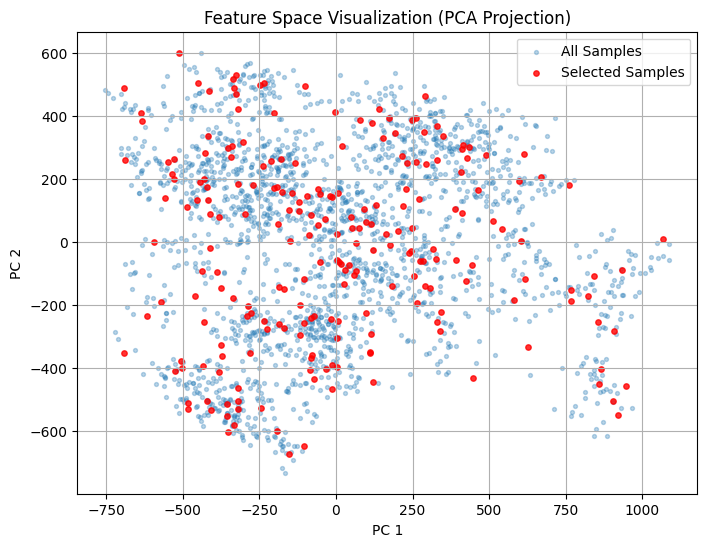

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ---------- Load features ----------
features = np.load("/content/drive/MyDrive/synapse_features/features_flat.npy")   # shape = (N, D)

# ---------- Load selected indices ----------
with open("/content/drive/MyDrive/gpu_synapse/not_required/Density_221_from_ActiveFT22.json", "r") as f:
    selected_indices = json.load(f)
selected_indices = np.array(selected_indices, dtype=int)

# Create masks
all_idx = np.arange(len(features))
mask_selected = np.zeros(len(features), dtype=bool)
mask_selected[selected_indices] = True

# ---------- 2D Projection (PCA is fast) ----------
pca = PCA(n_components=2)
proj = pca.fit_transform(features)

# ---------- Plot ----------
plt.figure(figsize=(8,6))

# full dataset
plt.scatter(proj[~mask_selected, 0], proj[~mask_selected, 1],
            s=8, alpha=0.3, label="All Samples")

# selected subset
plt.scatter(proj[mask_selected, 0], proj[mask_selected, 1],
            s=15, color='red', alpha=0.8, label="Selected Samples")

plt.title("Feature Space Visualization (PCA Projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.grid(True)
plt.savefig("pca.png", dpi=300, bbox_inches='tight')
plt.show()


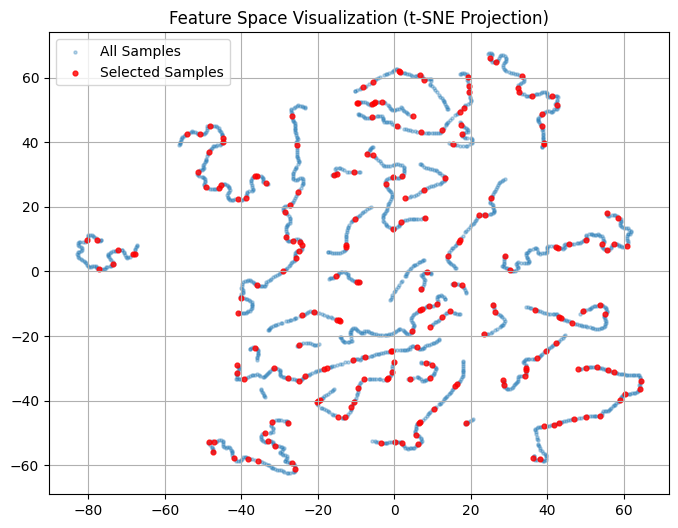

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200)
proj_tsne = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(proj_tsne[~mask_selected,0], proj_tsne[~mask_selected,1],
            s=5, alpha=0.3, label="All Samples")
plt.scatter(proj_tsne[mask_selected,0], proj_tsne[mask_selected,1],
            s=12, color='red', alpha=0.8, label="Selected Samples")

plt.title("Feature Space Visualization (t-SNE Projection)")
plt.legend()
plt.grid(True)
plt.savefig("t-sne.png", dpi=300, bbox_inches='tight')
plt.show()


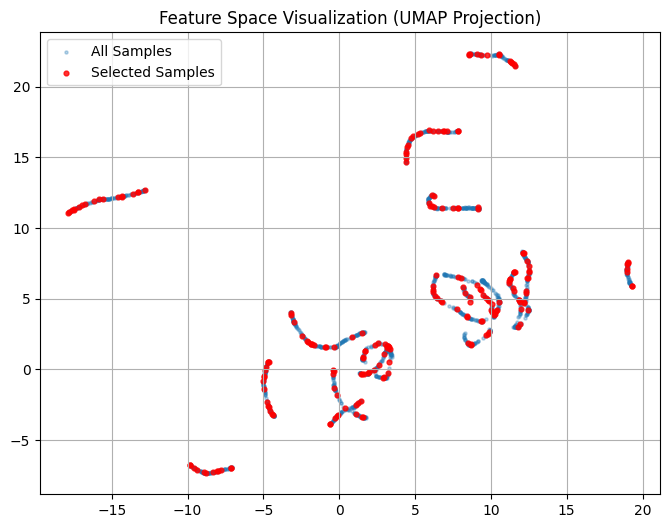

In [ ]:
import umap
import matplotlib.pyplot as plt

# UMAP projection
umap_model = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='euclidean')
proj_umap = umap_model.fit_transform(features)

plt.figure(figsize=(8,6))
plt.scatter(proj_umap[~mask_selected,0], proj_umap[~mask_selected,1],
            s=5, alpha=0.3, label="All Samples")
plt.scatter(proj_umap[mask_selected,0], proj_umap[mask_selected,1],
            s=12, color='red', alpha=0.8, label="Selected Samples")

plt.title("Feature Space Visualization (UMAP Projection)")
plt.legend()
plt.grid(True)
plt.savefig("umap.png", dpi=300, bbox_inches='tight')
plt.show()


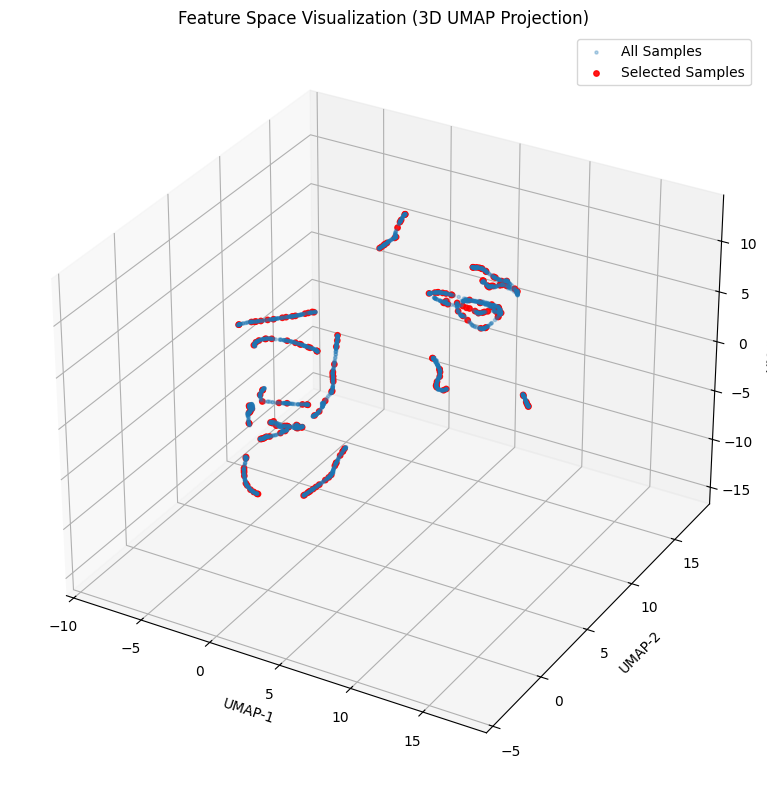

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# features: your (N, D) feature matrix
# mask_selected: boolean mask of shape (N,) for selected samples

# ---- UMAP 3D Projection ----
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean'
)

proj_umap_3d = umap_3d.fit_transform(features)

# ---- Plot ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# All samples (light)
ax.scatter(
    proj_umap_3d[~mask_selected, 0],
    proj_umap_3d[~mask_selected, 1],
    proj_umap_3d[~mask_selected, 2],
    s=5, alpha=0.3, label="All Samples"
)

# Selected samples (highlighted)
ax.scatter(
    proj_umap_3d[mask_selected, 0],
    proj_umap_3d[mask_selected, 1],
    proj_umap_3d[mask_selected, 2],
    s=15, color='red', alpha=0.9, label="Selected Samples"
)

# Labels
ax.set_title("Feature Space Visualization (3D UMAP Projection)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")

ax.legend()
plt.tight_layout()
plt.savefig("umap_3d.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np

mask = np.load("path/to/one_label.npz")["label"]   # (H, W)

# Count
unique, counts = np.unique(mask, return_counts=True)
print("Raw counts:", dict(zip(unique, counts)))

# Remove background (0)
class_counts = {int(u): int(c) for u, c in zip(unique, counts) if u != 0}

total = sum(class_counts.values())

# Percentages
for cls, cnt in class_counts.items():
    pct = 100 * cnt / total
    print(f"Class {cls}: {pct:.2f}%")
